In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder)
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.feature_selection import SelectKBest,f_classif
from scipy import stats
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# **partie 1: chargement et vue d'ensemble**

In [ ]:
df =pd.read_csv('/content/updated_pollution_dataset (1).csv')

In [ ]:
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


* Quelle est la distribution de la qualité de l’air (Good / Moderate / Hazardous) ?
* Quels sont les polluants les plus fréquents (PM2.5, PM10, NO2, etc.) ?
* Existe-t-il une relation entre PM2.5 et la qualité de l’air ?
* La densité de population influence-t-elle la pollution ?
* La proximité des zones industrielles affecte-t-elle la qualité de l’air ?
* La température et l’humidité ont-elles un impact ?
* Quels sont les facteurs les plus influents sur la pollution ?
#**Machine Learning**
* Peut-on prédire la qualité de l’air ?
* Quelles variables sont les plus importantes ?
* Classification : Good / Moderate / Hazardous
* Régression : prédire le niveau de pollution
#**Applications réelles**
* Comment améliorer la qualité de l’air ?
* Où réduire l’activité industrielle ?
* :Quelles zones sont les plus à risque ?





aperçue rapide

In [ ]:
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


**des informations  générales**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


**statisque descriptive**

In [ ]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


# **partie2 : analyse exploratoire - EDA**

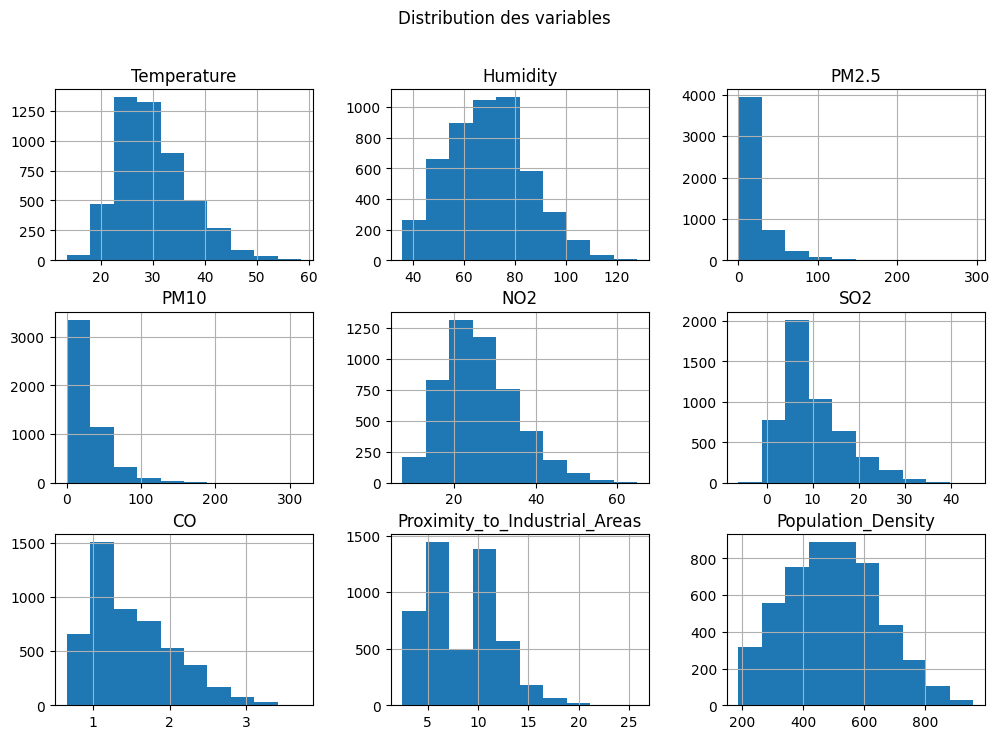

In [ ]:
df.hist(figsize=(12, 8))
plt.suptitle("Distribution des variables")
plt.show()

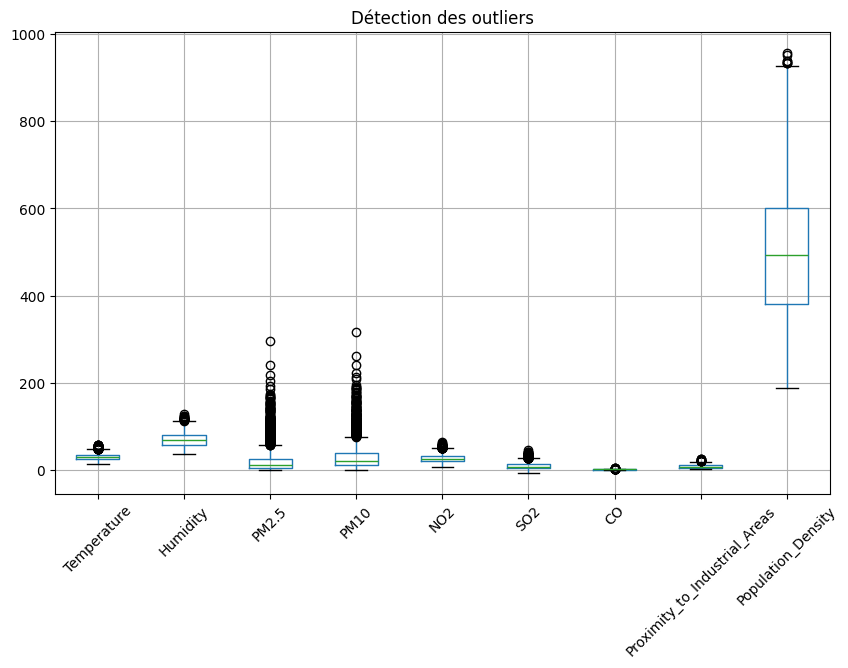

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title("Détection des outliers")
plt.xticks(rotation=45)
plt.show()

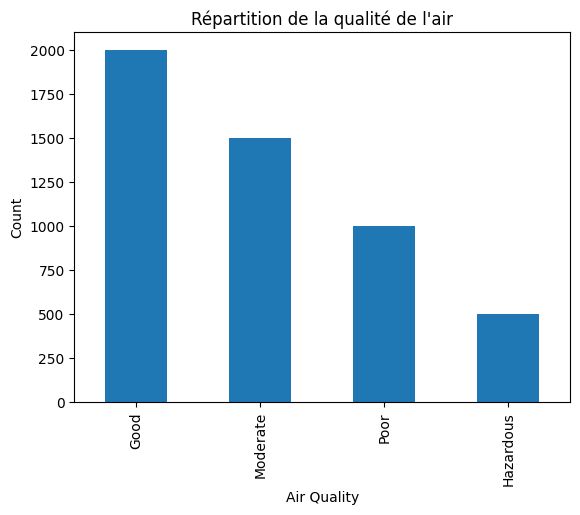

In [ ]:
air_counts = df['Air Quality'].value_counts()

plt.figure()
air_counts.plot(kind='bar')
plt.title("Répartition de la qualité de l'air")
plt.xlabel("Air Quality")
plt.ylabel("Count")
plt.show()

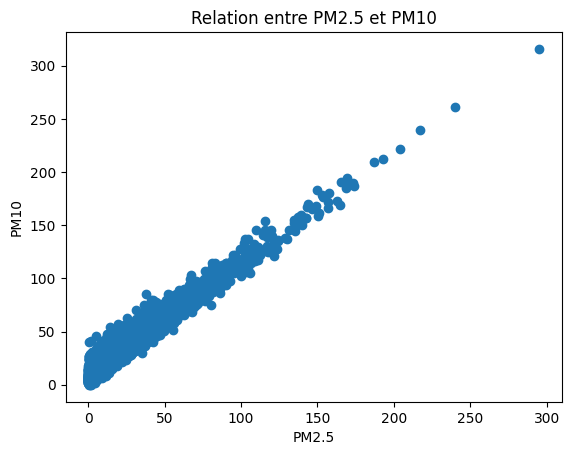

In [ ]:
plt.figure()
plt.scatter(df['PM2.5'], df['PM10'])
plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.title("Relation entre PM2.5 et PM10")
plt.show()

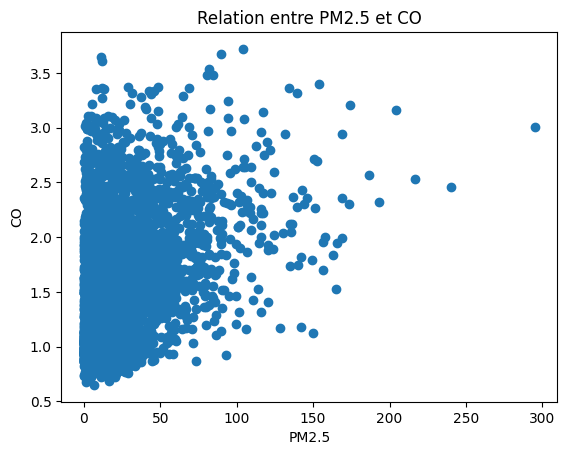

In [ ]:
plt.figure()
plt.scatter(df['PM2.5'], df['CO'])
plt.xlabel("PM2.5")
plt.ylabel("CO")
plt.title("Relation entre PM2.5 et CO")
plt.show()

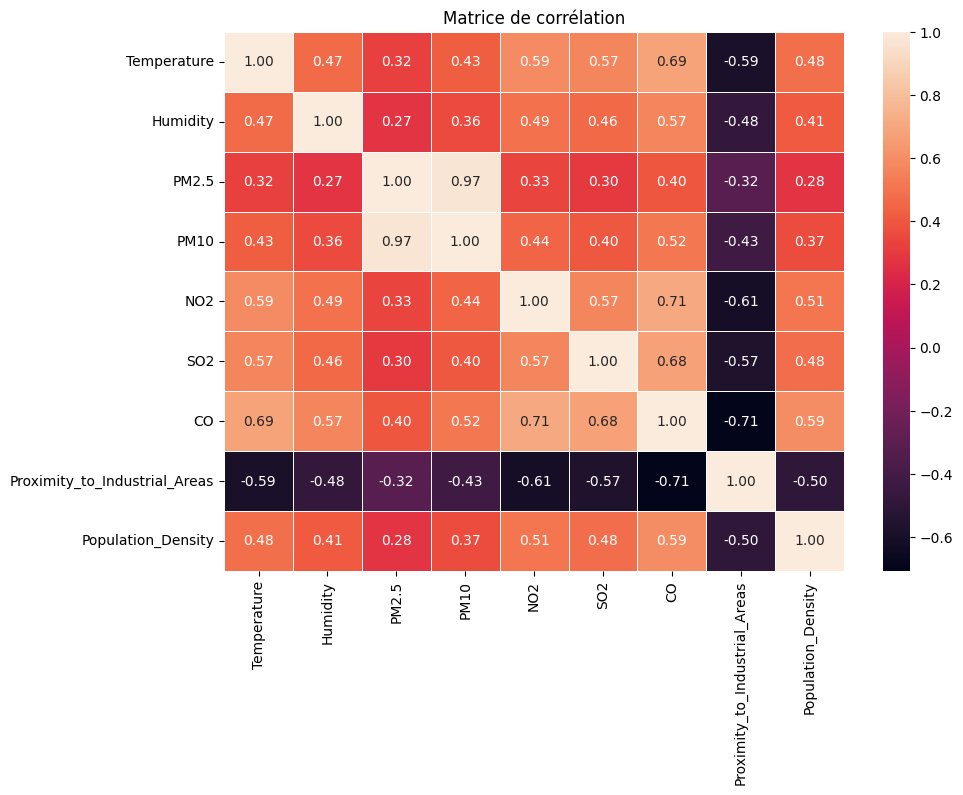

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

#**Partie 3 : Nettoyage - Valeurs manquants**


**carte des valeurs manquantes**


In [ ]:
missing=df.isnull().sum().sort_values(ascending=False)
missing

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


# **Partie4 : Traitement des outliers**

Ce sont les outliers présents, car les autres valeurs aberrantes des gaz sont normales dans les zones Hazardous

In [ ]:
print(f"Number of negative PM10 values: {(df['PM10'] < 0).sum()}")
print(f"Number of negative SO2 values: {(df['SO2'] < 0).sum()}")

Number of negative PM10 values: 1
Number of negative SO2 values: 30


**supprimer les outliers**

In [ ]:
print(f"Original DataFrame shape: {df.shape}")
df = df[(df['PM10'] >= 0) & (df['SO2'] >= 0)]
print(f"New DataFrame shape after dropping negative values: {df.shape}")

Original DataFrame shape: (5000, 10)
New DataFrame shape after dropping negative values: (4969, 10)


In [ ]:
df = df.reset_index(drop=True)

# **Prtie 5: Feature Engineering**

Création de la variable "Zone" basée sur un indice de pollution
 afin de distinguer les zones urbaines et rurales.

In [ ]:


df['pollution_index'] = (
    df['PM2.5'] * 0.3 +
    df['PM10'] * 0.2 +
    df['NO2'] * 0.2 +
    df['SO2'] * 0.1 +
    df['CO'] * 0.1 +
    df['Population_Density'] * 0.05 +
    df['Proximity_to_Industrial_Areas'] * 0.05)

threshold = df['pollution_index'].mean()

df['Zone'] = np.where(df['pollution_index'] > threshold, 'Urban', 'Rural')


In [ ]:
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality,pollution_index,Zone,Air Quality_enc,zone_enc
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate,26.277,Rural,1.0,0
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate,41.274,Rural,1.0,0
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate,52.283,Urban,1.0,1
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good,34.540,Rural,0.0,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good,26.096,Rural,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous,110.411,Urban,3.0,1
4965,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate,49.099,Urban,1.0,1
4966,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate,36.013,Rural,1.0,0
4967,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good,30.249,Rural,0.0,0


# **Paetie 6 : test des hypotheses**

division data

In [ ]:
urbain = df[df['Zone'] == 'Urban']
rural = df[df['Zone'] == 'Rural']

gaze polluant

In [ ]:
urbain_data = urbain['PM2.5'].dropna()
rural_data = rural['PM2.5'].dropna()

T-test

In [ ]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(urbain_data, rural_data, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 39.77312104666373
p-value: 2.4323664087113283e-261


 Hypothèses

In [ ]:
alpha = 0.05

print("\nHypothèses:")
print("H0: Il n'y a pas de différence significative entre Urban et Rural")
print("H1: Il existe une différence significative entre Urban et Rural")



Hypothèses:
H0: Il n'y a pas de différence significative entre Urban et Rural
H1: Il existe une différence significative entre Urban et Rural


Décision

In [ ]:
if p_value < alpha:
    print("\nConclusion: H0 rejetée → différence significative")
else:
    print("\nConclusion: H0 acceptée → pas de différence significative")


Conclusion: H0 rejetée → différence significative



# **Partie 7 :Encodage des variables catégorielles**




Label Encoding : Air Quality

In [ ]:

order = ['Good', 'Moderate', 'Poor', 'Hazardous']
enc = OrdinalEncoder(categories=[order])
df['Air Quality_enc'] = enc.fit_transform(df[['Air Quality']])


In [ ]:
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality,pollution_index,Zone,Air Quality_enc,zone_enc
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate,26.277,Rural,1.0,0
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate,41.274,Rural,1.0,0
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate,52.283,Urban,1.0,1
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good,34.540,Rural,0.0,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good,26.096,Rural,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous,110.411,Urban,3.0,1
4965,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate,49.099,Urban,1.0,1
4966,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate,36.013,Rural,1.0,0
4967,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good,30.249,Rural,0.0,0


Label Encoding : zone

In [ ]:
le = LabelEncoder()
df['zone_enc'] = le.fit_transform(df['Zone'])

# **La division de dataset**

In [ ]:
X = df.drop(['Air Quality','Air Quality_enc', 'Zone'], axis=1)
y = df['Air Quality_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


l'équilibre de data train : Il augmente la classe minoritaire pour éviter que le modèle soit biaisé.

In [ ]:
sm = SMOTE()
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# **Partie 8 :la normalisation des données**

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# **Partie 9 :Machine learning**

Random Forest

In [ ]:

model = RandomForestClassifier()
model.fit(X_train_scaled, y_train_res)

RandomForestClassifier()

**Les métriques d’évaluation**

In [ ]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[390   0   0   0]
 [  0 302  12   0]
 [  0   5 173  17]
 [  0   0   8  87]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       390
         1.0       0.98      0.96      0.97       314
         2.0       0.90      0.89      0.89       195
         3.0       0.84      0.92      0.87        95

    accuracy                           0.96       994
   macro avg       0.93      0.94      0.93       994
weighted avg       0.96      0.96      0.96       994


Accuracy Score:
0.9577464788732394
